### Import library

In [20]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
import os
import shap
import pickle
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)


### Load dataset 

In [2]:
df = pd.read_csv('../dataset/data/train.csv')
df.head(20)

,Timestamp,Open,High,Low,Close,Volume
0,1.553935e+09,4071.17,4071.17,4067.74,4067.74,4.587708
1,1.539865e+09,6431.90,6432.91,6429.81,6432.91,5.358719
2,1.379555e+09,127.96,127.96,127.80,127.80,0.457695
3,1.762841e+09,105322.00,105322.00,105266.00,105267.00,0.339559
4,1.446742e+09,385.77,386.92,385.76,386.92,22.224000
5,1.700457e+09,37354.00,37354.00,37354.00,37354.00,15.626177
6,1.340119e+09,6.47,6.47,6.47,6.47,0.000000
7,1.539675e+09,6433.49,6433.49,6428.79,6428.79,3.068286
8,1.720013e+09,60554.00,60558.00,60529.00,60529.00,0.697651
9,1.727068e+09,63877.00,63877.00,63683.00,63683.00,9.207357


### Time Conversion & Resampling:

In [3]:
# ubah timestamp ke datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'].astype(int), unit='s')

# set sebagai index (wajib untuk time series)
df.set_index('Timestamp', inplace=True)

data = df['Close']

data.head()

Timestamp
2019-03-30 08:38:00      4067.74
2018-10-18 12:24:00      6432.91
2013-09-19 01:45:00       127.80
2025-11-11 05:58:00    105267.00
2015-11-05 16:39:00       386.92
Name: Close, dtype: float64

In [4]:
data = data.resample('1h').mean().dropna()

#### Missing Data Imputation:

In [5]:
df.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [6]:
print("Data Training")
df.describe()

Data Training


,Open,High,Low,Close,Volume
count,6.012038e+06,6.012038e+06,6.012038e+06,6.012038e+06,6.012038e+06
mean,2.275733e+04,2.276539e+04,2.274909e+04,2.275735e+04,5.050939e+00
std,3.096599e+04,3.097441e+04,3.095750e+04,3.096602e+04,2.189686e+01
min,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,4.517900e+02,4.519700e+02,4.515500e+02,4.517900e+02,2.120705e-02
50%,7.719400e+03,7.723890e+03,7.714195e+03,7.719500e+03,4.573510e-01
75%,3.613171e+04,3.615650e+04,3.610400e+04,3.613189e+04,2.853782e+00
max,1.261980e+05,1.262390e+05,1.261580e+05,1.262020e+05,5.853852e+03


### Stationarity Audit:

In [7]:


hasil = adfuller(data)

print("ADF Statistic:", hasil[0])
print("p-value:", hasil[1])
print("Critical Values:")
for key, value in hasil[4].items():
    print(f"{key}: {value}")

ADF Statistic: -0.6386821633850991
p-value: 0.8619997402390778
Critical Values:
1%: -3.430402240246844
5%: -2.8615630894218396
10%: -2.566782289682375


### Temporal Transformation

In [8]:
data_diff = data.diff().dropna()

hasil_diff = adfuller(data_diff)

print("p-value setelah differencing:", hasil_diff[1])

p-value setelah differencing: 0.0


### Autocorrelation Check:

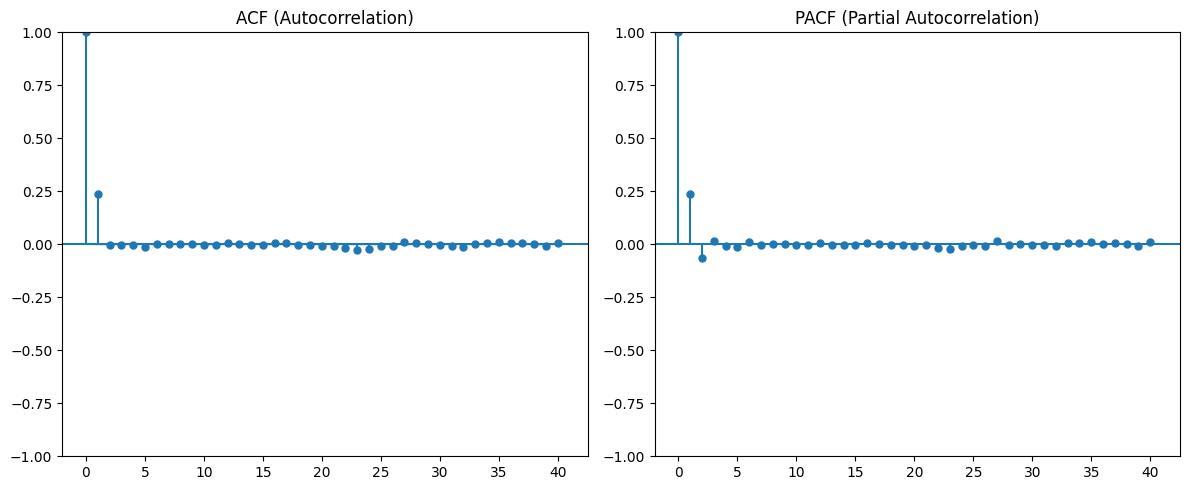

In [9]:


# gunakan data yang SUDAH stasioner (hasil differencing)
plt.figure(figsize=(12,5))

# ACF
plt.subplot(1,2,1)
plot_acf(data_diff, lags=40, ax=plt.gca())
plt.title('ACF (Autocorrelation)')

# PACF
plt.subplot(1,2,2)
plot_pacf(data_diff, lags=40, ax=plt.gca(), method='ywm')
plt.title('PACF (Partial Autocorrelation)')

plt.tight_layout()
plt.show()

### Scalling data 

In [10]:
scaler = MinMaxScaler()

# gunakan data asli (bukan differencing) untuk LSTM
scaled_data = scaler.fit_transform(data.values.reshape(-1, 1))

### Membuat Sequence

In [11]:
def create_dataset(data, time_step=24):  # 24 jam (karena sudah hourly)
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])
    return np.array(X), np.array(y)

TIME_STEP = 24
X, y = create_dataset(scaled_data, TIME_STEP)

X.shape, y.shape

((125229, 24, 1), (125229, 1))

### Split data

In [12]:

X_train = X
y_train = y

### Build Model LSTM

In [13]:


def build_model(units=50, dropout=0.2):
    model = Sequential()
    model.add(Input(shape=(TIME_STEP, 1)))
    model.add(LSTM(units, return_sequences=True))
    model.add(Dropout(dropout))
    
    model.add(LSTM(units))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse')
    return model

In [21]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

### Tuning

In [22]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

best_val_loss = float("inf")
best_model = None
best_params = None

for units in [32, 50, 64]:
    for dropout in [0.1, 0.2]:

        K.clear_session()

        model = build_model(units, dropout)

        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=20,
            batch_size=64,
            callbacks=[early_stop],
            verbose=0
        )

        val_loss = min(history.history['val_loss'])

        print(
            f"Units={units}, "
            f"Dropout={dropout}, "
            f"Val Loss={val_loss:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model
            best_params = {
                "units": units,
                "dropout": dropout
            }

print("\n===== BEST MODEL =====")
print("Units      :", best_params["units"])
print("Dropout    :", best_params["dropout"])
print("Val Loss   :", best_val_loss)

Units=32, Dropout=0.1, Val Loss=0.000391
Units=32, Dropout=0.2, Val Loss=0.000477
Units=50, Dropout=0.1, Val Loss=0.000152
Units=50, Dropout=0.2, Val Loss=0.000327
Units=64, Dropout=0.1, Val Loss=0.000199
Units=64, Dropout=0.2, Val Loss=0.000250

===== BEST MODEL =====
Units      : 50
Dropout    : 0.1
Val Loss   : 0.00015219100168906152


In [38]:
# Simpan model
best_model.save("../model/lstm_forecasting.keras")

# Simpan scaler
with open("../model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model dan scaler berhasil disimpan")

Model dan scaler berhasil disimpan


### SHAP

100%|██████████| 10/10 [04:09<00:00, 24.94s/it]


Shape SHAP values : (10, 24)
Shape Sample data : (10, 24)


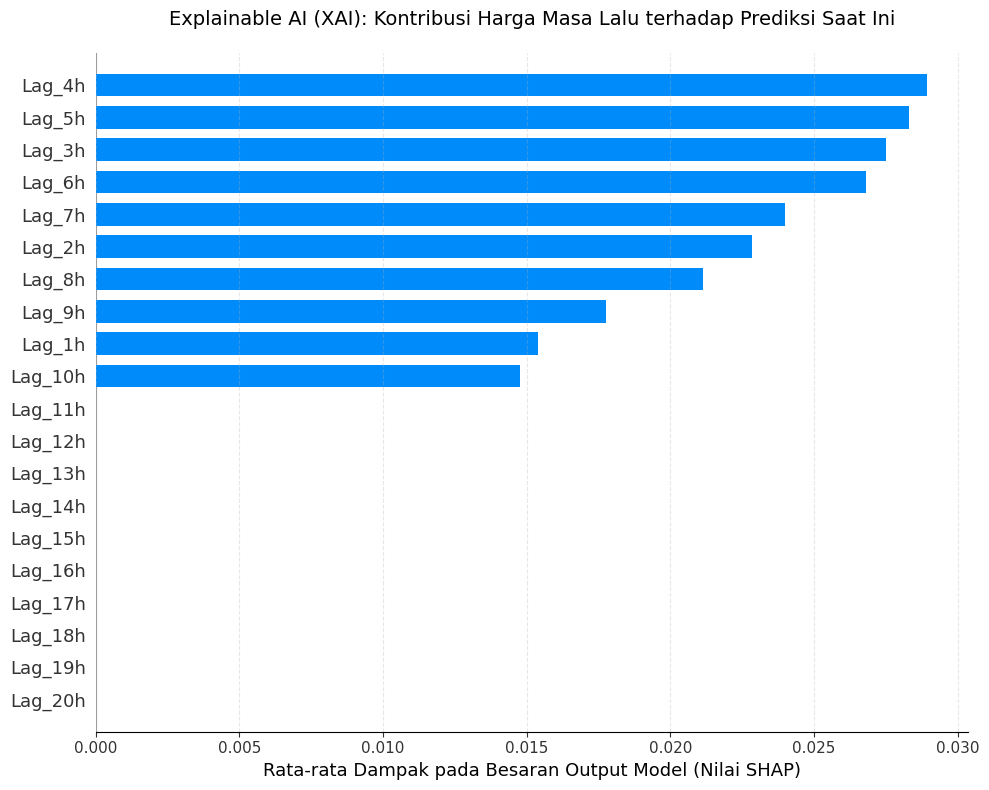

In [24]:
# 1. Define Feature Names (Pengaruh 24 jam ke belakang)
feature_names = [f'Lag_{24-i}h' for i in range(24)]

# 2. Prepare Data
# Flatten X_train menjadi 2D untuk SHAP (samples, features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Gunakan shap.sample agar pemilihan background data lebih representatif dan stabil
background_data = shap.sample(X_train_flat, 50) 
sample_data = X_train_flat[:10]

# 3. Wrapper untuk Model LSTM
def predict_wrapper(x):
    # Kembalikan ke bentuk 3D (samples, timesteps, features) untuk input LSTM
    x_3d = x.reshape(x.shape[0], 24, 1)
    # Prediksi dan ratakan ke 1D array
    return best_model.predict(x_3d, verbose=0).flatten()

# 4. Hitung SHAP values dengan KernelExplainer
explainer = shap.KernelExplainer(predict_wrapper, background_data)
shap_values = explainer.shap_values(sample_data)

# 5. Penanganan Dimensi yang Aman
# KernelExplainer kadang mengembalikan List (jika multi-output), kita ambil elemen pertamanya
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Pastikan shap_values adalah numpy array 2D
shap_values = np.array(shap_values)

print("Shape SHAP values :", shap_values.shape)
print("Shape Sample data :", sample_data.shape)

# 6. Visualisasi Plot
plt.clf() # Membersihkan kanvas sebelumnya (mencegah plot kosong)

# Generate plot tanpa menampilkan langsung (show=False)
shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

# Kustomisasi Figure Matplotlib SETELAH plot SHAP dibuat
fig = plt.gcf()
fig.set_size_inches(10, 8) # Atur ukuran di sini
plt.title("Explainable AI (XAI): Kontribusi Harga Masa Lalu terhadap Prediksi Saat Ini", fontsize=14, pad=20)
plt.xlabel("Rata-rata Dampak pada Besaran Output Model (Nilai SHAP)")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()

# Tampilkan plot
plt.show()

In [40]:


model = load_model("../model/lstm_forecasting.keras")

with open("../model/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print("Model dan scaler berhasil dimuat")

Model dan scaler berhasil dimuat


In [26]:
# %%
test_df = pd.read_csv("../dataset/data/test.csv")

print(test_df.head())
print(test_df.shape)

      Timestamp      Open      High       Low     Close    Volume
0  1.710000e+09  68337.00  68347.00  68333.00  68333.00  1.873429
1  1.652527e+09  29473.94  29485.67  29468.42  29468.42  1.347478
2  1.646242e+09  44046.03  44047.45  43986.67  43986.67  0.275159
3  1.669388e+09  16435.00  16435.00  16432.00  16433.00  0.442565
4  1.713196e+09  66193.00  66193.00  66192.00  66192.00  0.564461
(1503010, 6)


In [27]:
print("Data Test")
test_df.describe()

Data Test


,Timestamp,Open,High,Low,Close,Volume
count,1.503010e+06,1.503010e+06,1.503010e+06,1.503010e+06,1.503010e+06,1.503010e+06
mean,1.550847e+09,2.276625e+04,2.277431e+04,2.275801e+04,2.276624e+04,5.045259e+00
std,1.302078e+08,3.098675e+04,3.099520e+04,3.097825e+04,3.098674e+04,2.138911e+01
min,1.325412e+09,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,1.438020e+09,4.517000e+02,4.519125e+02,4.515100e+02,4.517500e+02,2.119356e-02
50%,1.550843e+09,7.710350e+03,7.715365e+03,7.706000e+03,7.711045e+03,4.563918e-01
75%,1.663679e+09,3.618499e+04,3.620890e+04,3.615753e+04,3.618357e+04,2.851814e+00
max,1.776384e+09,1.262020e+05,1.262720e+05,1.261570e+05,1.261720e+05,2.958478e+03


In [28]:
# %%
# Ubah timestamp menjadi datetime
test_df['Timestamp'] = pd.to_datetime(
    test_df['Timestamp'].astype(int),
    unit='s'
)

# Jadikan index
test_df.set_index('Timestamp', inplace=True)

# Ambil kolom Close
data_test = test_df['Close']

# Resampling 1 jam
data_test = data_test.resample('1h').mean().dropna()

print(data_test.head())
print("Jumlah data:", len(data_test))

Timestamp
2012-01-01 10:00:00    4.58
2012-01-01 11:00:00    4.58
2012-01-01 12:00:00    4.58
2012-01-01 13:00:00    4.58
2012-01-01 14:00:00    4.58
Name: Close, dtype: float64
Jumlah data: 125252


In [29]:
# %%
scaled_test = scaler.transform(
    data_test.values.reshape(-1,1)
)

print(scaled_test.shape)

(125252, 1)


In [30]:
# %%
def create_dataset_test(data, time_step=24):

    X = []
    y = []

    for i in range(len(data) - time_step):
        X.append(data[i:i+time_step])
        y.append(data[i+time_step])

    return np.array(X), np.array(y)

TIME_STEP = 24

X_test, y_test = create_dataset_test(
    scaled_test,
    TIME_STEP
)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_test : (125228, 24, 1)
y_test : (125228, 1)


In [31]:
# %%
y_pred_scaled = model.predict(X_test)

print(y_pred_scaled.shape)

3914/3914 ━━━━━━━━━━━━━━━━━━━━ 32s 8ms/step
(125228, 1)


In [32]:
# %%
y_pred = scaler.inverse_transform(
    y_pred_scaled
)

y_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

print(y_actual.shape)
print(y_pred.shape)

(125228, 1)
(125228, 1)


In [33]:
print("\nPrediksi Pertama")

for i in range(10):
    print(
        f"Actual={y_actual[i][0]:.2f} | "
        f"Pred={y_pred[i][0]:.2f}"
    )


Prediksi Pertama
Actual=5.00 | Pred=78.33
Actual=5.00 | Pred=78.35
Actual=5.00 | Pred=78.36
Actual=5.00 | Pred=78.38
Actual=5.00 | Pred=78.38
Actual=5.00 | Pred=78.39
Actual=5.00 | Pred=78.40
Actual=5.00 | Pred=78.40
Actual=5.00 | Pred=78.40
Actual=5.00 | Pred=78.41


In [35]:
# %%


mae = mean_absolute_error(
    y_actual,
    y_pred
)

mse = mean_squared_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(mse)

mape = mean_absolute_percentage_error(
    y_actual,
    y_pred
)

r2 = r2_score(
    y_actual,
    y_pred
)

print("R2 Score:", r2)

print("="*40)
print("HASIL PENGUJIAN DATA TEST")
print("="*40)
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAPE :", mape)

R2 Score: 0.999335506657627
HASIL PENGUJIAN DATA TEST
MAE  : 434.8262649674317
MSE  : 637410.0010916089
RMSE : 798.3796096416847
MAPE : 0.8584632872671981


In [36]:
# %%
n = len(y_actual)

k = model.count_params()

aic = n * np.log(mse) + 2 * k

bic = n * np.log(mse) + k * np.log(n)

print("AIC :", aic)
print("BIC :", bic)

AIC : 1734995.3047999498
BIC : 2033471.4127164297


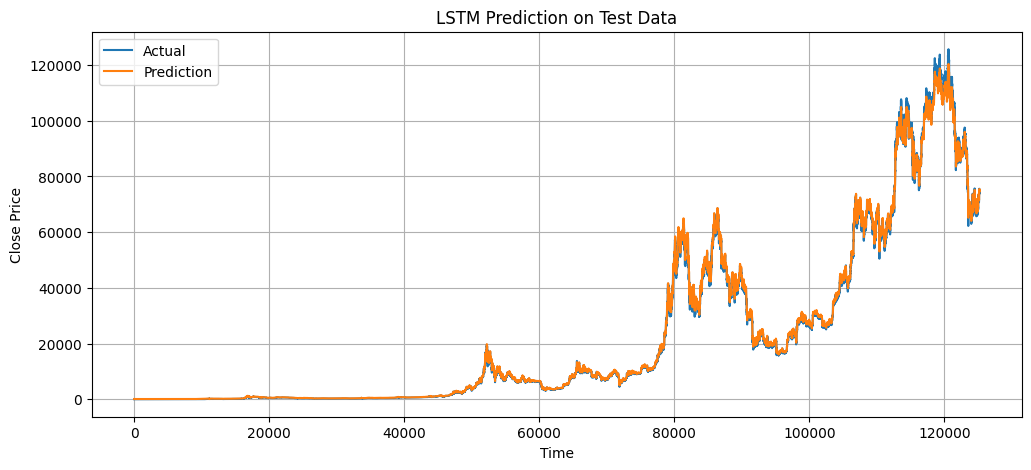

In [37]:
# %%
plt.figure(figsize=(12,5))

plt.plot(
    y_actual,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Prediction"
)

plt.title("LSTM Prediction on Test Data")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.grid(True)

plt.show()